In [144]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import pandas as pd

Data loading

In [145]:


client_data = pd.read_csv('/Users/manhaawan/Documents/Energy Consumption Project/client.csv')
gas_prices = pd.read_csv('/Users/manhaawan/Documents/Energy Consumption Project/gas_prices.csv')
historical_weather = pd.read_csv('/Users/manhaawan/Documents/Energy Consumption Project/historical_weather.csv')
train = pd.read_csv('/Users/manhaawan/Documents/Energy Consumption Project/train.csv')


In [146]:
#Datetime Conversion
train["datetime"] = pd.to_datetime(train["datetime"], errors='coerce')
historical_weather["datetime"] = pd.to_datetime(historical_weather["datetime"], errors='coerce')
train["date"] = train["datetime"].dt.date
historical_weather["date"] = historical_weather["datetime"].dt.date


Data Preprocessing

In [147]:

#Drop Duplicates
client_data = client_data.drop_duplicates(subset='data_block_id')
historical_weather = historical_weather.drop_duplicates(subset='data_block_id')
gas_prices = gas_prices.drop_duplicates(subset='data_block_id')

In [148]:

#Merge DataFrames
merge_dfs = [client_data, historical_weather, gas_prices]
merged_df = train.copy()
for df in merge_dfs:
    merged_df = merged_df.merge(df, on='data_block_id', how='left', suffixes=('', '_dup'))
merged_df = merged_df.loc[:, ~merged_df.columns.str.endswith('_dup')]

Feature Engineering

In [149]:

merged_df["hour"] = merged_df["datetime"].dt.hour
merged_df["dayofweek"] = merged_df["datetime"].dt.dayofweek
merged_df["month"] = merged_df["datetime"].dt.month
merged_df = merged_df.sort_values(by=["prediction_unit_id", "datetime"])
merged_df["target_lag_24h"] = merged_df.groupby("prediction_unit_id")["target"].shift(24)
merged_df["target_rolling_24h"] = merged_df.groupby("prediction_unit_id")["target"].rolling(24).mean().reset_index(0, drop=True)


In [150]:
#Aggregate Weather
weather_daily = historical_weather.groupby("date").agg({
    "temperature": "mean",
    "shortwave_radiation": "mean",
    "cloudcover_total": "mean",
    "windspeed_10m": "mean",
    "dewpoint": "mean",
    "rain": "mean",
    "surface_pressure": "mean",
    "snowfall": "mean",
    "winddirection_10m": "mean",
    "direct_solar_radiation": "mean",
    "diffuse_radiation": "mean"
}).reset_index().rename(columns={
    "temperature": "daily_avg_temp",
    "shortwave_radiation": "daily_avg_radiation",
    "cloudcover_total": "daily_avg_cloudcover",
    "windspeed_10m": "daily_avg_wind",
    "dewpoint": "daily_avg_dewpoint",
    "rain": "daily_avg_rain",
    "surface_pressure": "daily_avg_pressure",
    "snowfall": "daily_avg_snowfall",
    "winddirection_10m": "daily_avg_winddirection",
    "direct_solar_radiation": "daily_avg_direct_radiation",
    "diffuse_radiation": "daily_avg_diffuse_radiation"
})
merged_df["date"] = pd.to_datetime(merged_df["datetime"]).dt.date
merged_df = merged_df.merge(weather_daily, on="date", how="left")

In [151]:

# Filter to consumption
consumption_df = merged_df[merged_df["is_consumption"] == True].copy()

In [152]:

# Additional Lag Features
lags = [1, 6, 12, 24]
for l in lags:
    consumption_df[f"target_lag_{l}h"] = consumption_df.groupby("prediction_unit_id")["target"].shift(l)

# Rolling Mean Features
rolling_windows = [6, 12, 24]
for w in rolling_windows:
    consumption_df[f"target_roll_mean_{w}h"] = (
        consumption_df.groupby("prediction_unit_id")["target"].rolling(w).mean().reset_index(0, drop=True)
    )

# Lead Weather Features (6 hours ahead)
leads = [6]
for lead in leads:
    consumption_df[f"temp_lead_{lead}h"] = (
        consumption_df.groupby("prediction_unit_id")["daily_avg_temp"].shift(-lead)
    )
    consumption_df[f"radiation_lead_{lead}h"] = (
        consumption_df.groupby("prediction_unit_id")["daily_avg_radiation"].shift(-lead)
    )


FeatureSelection

In [153]:

# Drop NaNs from engineered features
lead_lag_features = [
    f"target_lag_{l}h" for l in lags
] + [
    f"target_roll_mean_{w}h" for w in rolling_windows
] + [
    f"temp_lead_{l}h" for l in leads
] + [
    f"radiation_lead_{l}h" for l in leads
]

base_features = [
    "hour", "dayofweek", "month",
    "lowest_price_per_mwh", "highest_price_per_mwh",
    "daily_avg_temp", "daily_avg_radiation", "daily_avg_cloudcover", "daily_avg_wind"
]

features = base_features + lead_lag_features

# Clean Data
consumption_df = consumption_df.dropna(subset=features + ["target"])
X = consumption_df[features].values
y = consumption_df["target"].values

Modeltraining


🔁 Fold 1
✅ Fold 1 Test RMSE: 17.4667


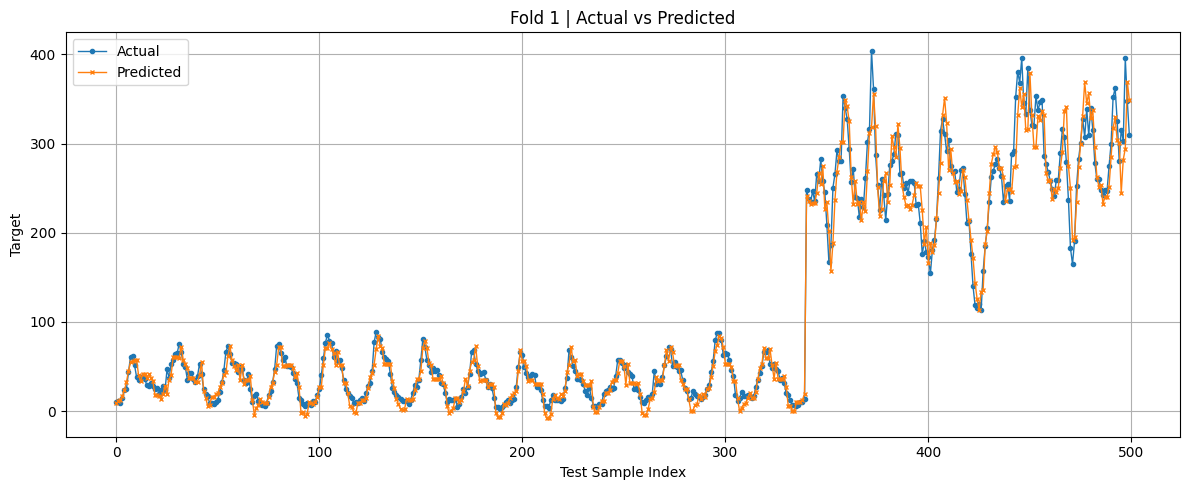


🔁 Fold 2
✅ Fold 2 Test RMSE: 30.4464

🔁 Fold 3
✅ Fold 3 Test RMSE: 32.9548

🔁 Fold 4
✅ Fold 4 Test RMSE: 30.9769

🔁 Fold 5
✅ Fold 5 Test RMSE: 29.6428

🔁 Fold 6
✅ Fold 6 Test RMSE: 28.8682

🔁 Fold 7
✅ Fold 7 Test RMSE: 98.3588

🔁 Fold 8
✅ Fold 8 Test RMSE: 157.5687

🔁 Fold 9
✅ Fold 9 Test RMSE: 159.9987

🔁 Fold 10
✅ Fold 10 Test RMSE: 151.3014

🔁 Fold 11
✅ Fold 11 Test RMSE: 173.9244

🔁 Fold 12
✅ Fold 12 Test RMSE: 151.6753

🔁 Fold 13
✅ Fold 13 Test RMSE: 158.6396

🔁 Fold 14
✅ Fold 14 Test RMSE: 152.9528

🔁 Fold 15
✅ Fold 15 Test RMSE: 134.2492

🔁 Fold 16
✅ Fold 16 Test RMSE: 37.0257

🔁 Fold 17
✅ Fold 17 Test RMSE: 37.3104

🔁 Fold 18
✅ Fold 18 Test RMSE: 33.8405

🔁 Fold 19
✅ Fold 19 Test RMSE: 42.0173

🔁 Fold 20
✅ Fold 20 Test RMSE: 49.7138

🔁 Fold 21
✅ Fold 21 Test RMSE: 57.5624

🔁 Fold 22
✅ Fold 22 Test RMSE: 37.0987

🔁 Fold 23
✅ Fold 23 Test RMSE: 36.4814

🔁 Fold 24
✅ Fold 24 Test RMSE: 31.6893

🔁 Fold 25
✅ Fold 25 Test RMSE: 43.1871


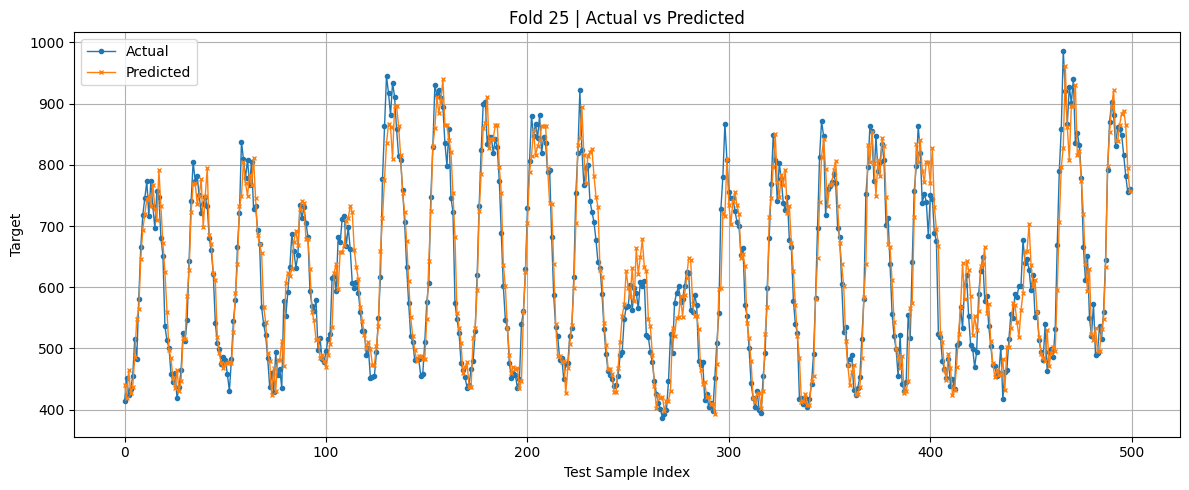


🔁 Fold 26
✅ Fold 26 Test RMSE: 50.4080

🔁 Fold 27
✅ Fold 27 Test RMSE: 48.0396

🔁 Fold 28
✅ Fold 28 Test RMSE: 52.2939

🔁 Fold 29
✅ Fold 29 Test RMSE: 44.8710

🔁 Fold 30
✅ Fold 30 Test RMSE: 41.6484

🔁 Fold 31
✅ Fold 31 Test RMSE: 36.8562

🔁 Fold 32
✅ Fold 32 Test RMSE: 6.1531

🔁 Fold 33
✅ Fold 33 Test RMSE: 4.0633

🔁 Fold 34
✅ Fold 34 Test RMSE: 4.7236

🔁 Fold 35
✅ Fold 35 Test RMSE: 6.7302

🔁 Fold 36
✅ Fold 36 Test RMSE: 6.8834

🔁 Fold 37
✅ Fold 37 Test RMSE: 6.8357

🔁 Fold 38
✅ Fold 38 Test RMSE: 7.0468

🔁 Fold 39
✅ Fold 39 Test RMSE: 6.9227

🔁 Fold 40
✅ Fold 40 Test RMSE: 8.9471

🔁 Fold 41
✅ Fold 41 Test RMSE: 7.6907

🔁 Fold 42
✅ Fold 42 Test RMSE: 6.7232

🔁 Fold 43
✅ Fold 43 Test RMSE: 5.9721

🔁 Fold 44
✅ Fold 44 Test RMSE: 5.7985

🔁 Fold 45
✅ Fold 45 Test RMSE: 4.8362

🔁 Fold 46
✅ Fold 46 Test RMSE: 5.7965

🔁 Fold 47
✅ Fold 47 Test RMSE: 5.5605

🔁 Fold 48
✅ Fold 48 Test RMSE: 6.1135

🔁 Fold 49
✅ Fold 49 Test RMSE: 5.5899

🔁 Fold 50
✅ Fold 50 Test RMSE: 8.2843


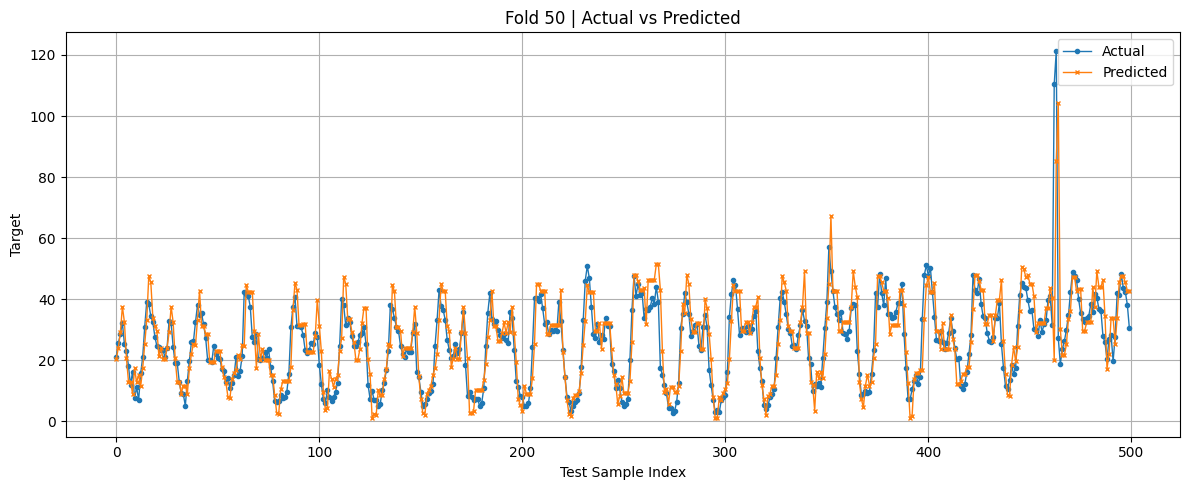

In [154]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# --- Rolling Window Split Function ---
def rolling_window_split(X, y, train_size, val_size, test_size, max_folds=3):
    n_samples = len(X)
    for fold in range(max_folds):
        start = fold * test_size
        train_end = start + train_size
        val_end = train_end + val_size
        test_end = val_end + test_size

        if test_end > n_samples:
            break

        train_idx = np.arange(start, train_end)
        val_idx = np.arange(train_end, val_end)
        test_idx = np.arange(val_end, test_end)

        yield train_idx, val_idx, test_idx


# --- Parameters ---
train_size = 150_000
val_size = 1_000
test_size = 500
max_folds = 50

all_y_test = []
all_y_pred = []
# --- Run Forecasting Loop ---
for fold, (train_idx, val_idx, test_idx) in enumerate(rolling_window_split(X, y, train_size, val_size, test_size, max_folds)):
    print(f"\n🔁 Fold {fold + 1}")

    # Split data
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test)

    # XGBoost Parameters
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 5,
        'eval_metric': 'rmse'
    }

    # Train model with early stopping
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,
        evals=[(dval, 'validation')],
        early_stopping_rounds=10,
        verbose_eval=False
    )

    # Predict on test set
    y_pred = model.predict(dtest)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"✅ Fold {fold + 1} Test RMSE: {rmse:.4f}")


    # Accumulate results
    all_y_test.append(y_test)
    all_y_pred.append(y_pred)
     
       # Plot only for fold 1, 25, 50 (adjust if max_folds < 50)
    if fold + 1 in [1, 25, 50]:
        plt.figure(figsize=(12, 5))
        plt.plot(y_test, label="Actual", marker='o', markersize=3, linewidth=1)
        plt.plot(y_pred, label="Predicted", marker='x', markersize=3, linewidth=1)
        plt.title(f"Fold {fold + 1} | Actual vs Predicted")
        plt.xlabel("Test Sample Index")
        plt.ylabel("Target")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


Visualisation


📊 Overall MAE across all folds: 33.2775


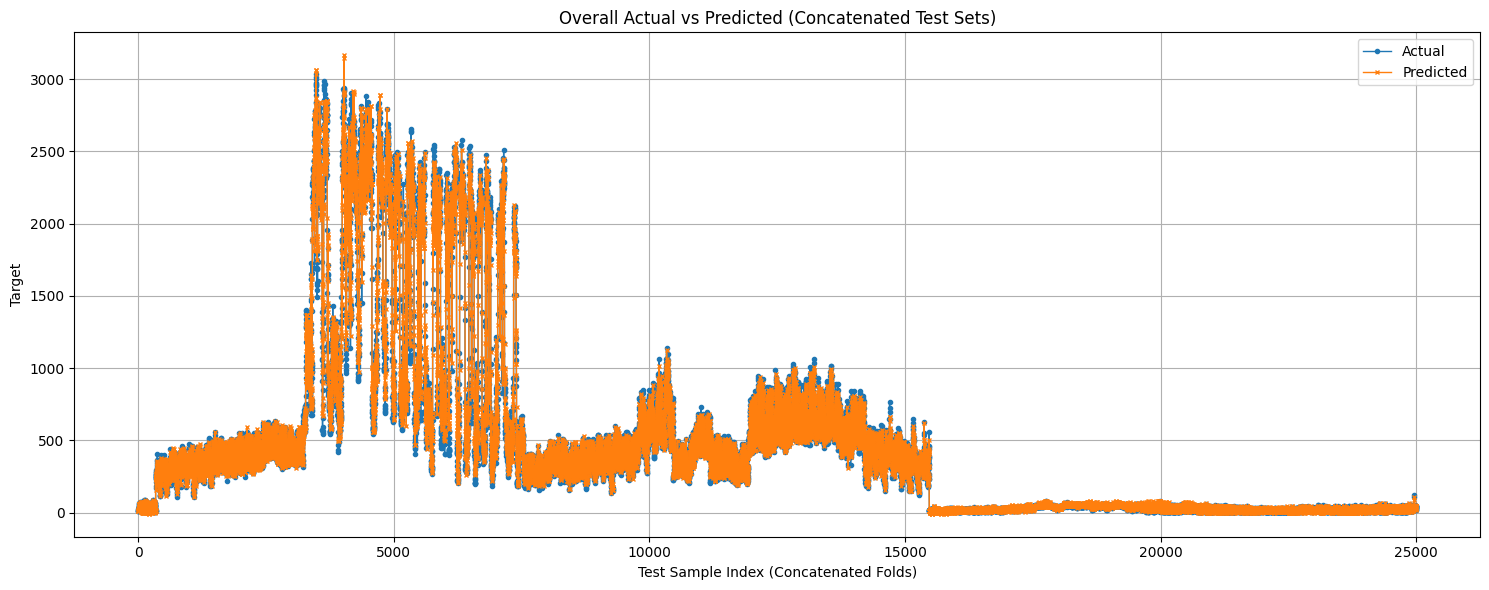

In [155]:
# --- After all folds ---
from sklearn.metrics import mean_absolute_error
# Concatenate all test results
all_y_test = np.concatenate(all_y_test)
all_y_pred = np.concatenate(all_y_pred)

# Compute overall metrics
mae = mean_absolute_error(all_y_test, all_y_pred)
print(f"\n📊 Overall MAE across all folds: {mae:.4f}")

# Plot overall actual vs predicted
plt.figure(figsize=(15, 6))
plt.plot(all_y_test, label="Actual", marker='o', markersize=3, linewidth=1)
plt.plot(all_y_pred, label="Predicted", marker='x', markersize=3, linewidth=1)
plt.title("Overall Actual vs Predicted (Concatenated Test Sets)")
plt.xlabel("Test Sample Index (Concatenated Folds)")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()